In [1]:
import pandas as pd
import numpy as np
import scipy.stats as st
import statsmodels.formula.api as smf
import statsmodels.stats as sms
import statsmodels.api as sm

import matplotlib.pyplot as plt
import plotly.express as px
import plotly.io as pio
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, Ridge, lasso_path, enet_path
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn import set_config
set_config(transform_output="pandas")

In [2]:
base = pio.templates["simple_white"]
custom_template = base.layout.template

custom_template.layout.update(
    margin=dict(l=50, r=50, t=20, b=50),
    xaxis=dict(
        title_standoff=0,
        ticks="outside",
        showgrid=True,
        gridcolor='#bbb'
    ),
    yaxis=dict(
        title_standoff=0,
        ticks="outside",
        showgrid=True,
        gridcolor='#bbb'
    ),
    colorscale=dict(
        sequential=px.colors.sequential.Inferno,
        diverging=px.colors.diverging.curl_r
    ),
    colorway=px.colors.qualitative.T10
)

pio.templates["tight"] = custom_template
pio.templates.default = "tight"

In [3]:
kc = pd.read_csv('kc_house_data.csv')

In [4]:
kc['date'] = pd.to_datetime(kc.date)

sqft_to_sqmeters = 0.09290303997

kc = kc.astype({'sqft_living': float, 'sqft_lot': float, 
                'sqft_above': float, 'sqft_basement': float,
                'sqft_living15': float, 'sqft_lot15': float,
                'yr_renovated': float, 'yr_built': float,
                'bedrooms': float, 'waterfront': float,
                'view': float, 'condition': float, 'grade': float})

kc.loc[:,['sqft_living', 'sqft_lot', 'sqft_above', 'sqft_basement', 'sqft_living15', 'sqft_lot15']] =\
kc.loc[:,['sqft_living', 'sqft_lot', 'sqft_above', 'sqft_basement', 'sqft_living15', 'sqft_lot15']] * sqft_to_sqmeters

kc.columns = ['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqm_living',
       'sqm_lot', 'floors', 'waterfront', 'view', 'condition', 'grade',
       'sqm_above', 'sqm_basement', 'yr_built', 'yr_renovated', 'zipcode',
       'lat', 'long', 'sqm_living15', 'sqm_lot15']

kc = kc.loc[:, ['id', 'date', 'price', 
            'floors', 'bedrooms', 'bathrooms', 
            'yr_built', 'yr_renovated',
            'waterfront', 'view', 'condition', 'grade', 
            'sqm_living', 'sqm_lot', 
            'sqm_above', 'sqm_basement',
            'sqm_living15', 'sqm_lot15',
            'lat', 'long']]

kc.loc[kc.sqm_basement == 0, 'sqm_basement'] = np.nan
kc.loc[kc.yr_renovated == 0, 'yr_renovated'] = np.nan

In [5]:
kc_log = kc.copy()
kc_log.loc[:, ['price', 'sqm_living', 'sqm_lot', 'sqm_above', 'sqm_basement', 'sqm_living15', 'sqm_lot15']] = \
np.log10(kc_log.loc[:, ['price', 'sqm_living', 'sqm_lot', 'sqm_above', 'sqm_basement', 'sqm_living15', 'sqm_lot15']])

In [6]:
kc_log.yr_renovated = kc_log.yr_renovated.fillna(kc_log.yr_built)
kc_log.loc[:,'sqm_basement'] = kc_log.loc[:,'sqm_basement'].fillna(0)
kc.yr_renovated = kc.yr_renovated.fillna(kc.yr_built)
kc.loc[:,'sqm_basement'] = kc.loc[:,'sqm_basement'].fillna(0)

In [7]:
kc_z=kc.copy()
for col in kc_z.drop(columns=['id', 'date']).columns:
    kc_z.loc[:,col] = st.zscore(kc_z.loc[:,col])

In [8]:
kc_X = kc.drop(columns=['id', 'date', 'price', 'sqm_above', 'lat', 'long'])

# kc_X = kc.drop(columns=['id', 'date', 'price', 'yr_renovated',
#                                 'sqm_above', 'sqm_basement',
#                                 'sqm_living15', 'sqm_lot15',
#                                 'lat', 'long'])

kc_y = kc.price

X_train, X_test, y_train, y_test = train_test_split(kc_X, kc_y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
np.logspace(start=1, stop=7, num=25, base=10)

array([1.00000000e+01, 1.77827941e+01, 3.16227766e+01, 5.62341325e+01,
       1.00000000e+02, 1.77827941e+02, 3.16227766e+02, 5.62341325e+02,
       1.00000000e+03, 1.77827941e+03, 3.16227766e+03, 5.62341325e+03,
       1.00000000e+04, 1.77827941e+04, 3.16227766e+04, 5.62341325e+04,
       1.00000000e+05, 1.77827941e+05, 3.16227766e+05, 5.62341325e+05,
       1.00000000e+06, 1.77827941e+06, 3.16227766e+06, 5.62341325e+06,
       1.00000000e+07])

In [10]:
path_models = {
"ridge": Ridge(alpha=2000, random_state=42),
"lasso": Lasso(alpha=22000, random_state=42, max_iter=10000),
"elastic_net": ElasticNet(l1_ratio=0.9, alpha=22000, random_state=42)
}

In [11]:
def model_paths(name, X, y, start, stop, num, base):
    model=path_models[name]
    coef_df = pd.DataFrame(data=0.0, index=range(100), columns=['alpha', 'r2', 'intercept'] + list(X.columns))
    i=0
    for a in np.logspace(start=start, stop=stop, num=num, base=base):
        model.alpha = a
        model.fit(X, y)
        coef_df.loc[i, 'alpha'] = a
        coef_df.loc[i, 'r2'] = model.score(X, y)
        coef_df.loc[i, 'intercept'] = model.intercept_
        coef_df.loc[i, 'floors':] = model.coef_
        i+=1
    return coef_df

In [12]:
result = model_paths('ridge', X_train_scaled, y_train, 2, 8, 100, 10)

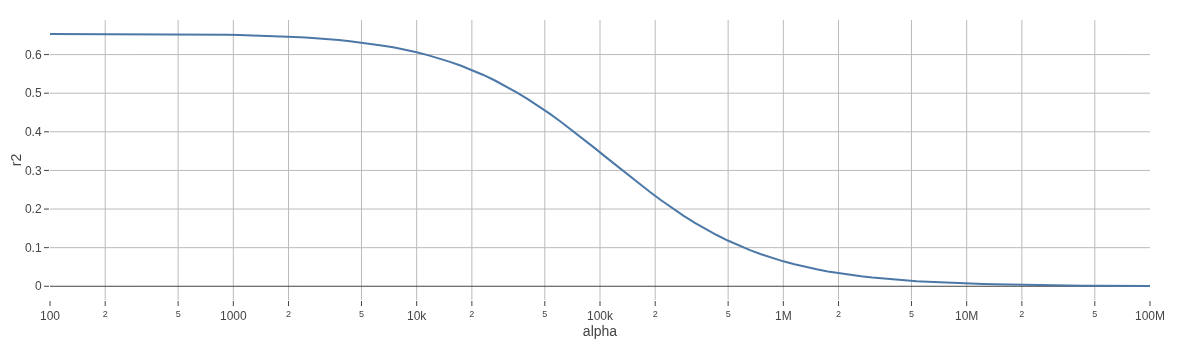

In [13]:
px.line(result, x='alpha', y='r2', log_x=True, width = 1200).show(renderer='png', width = 1200, height=350)

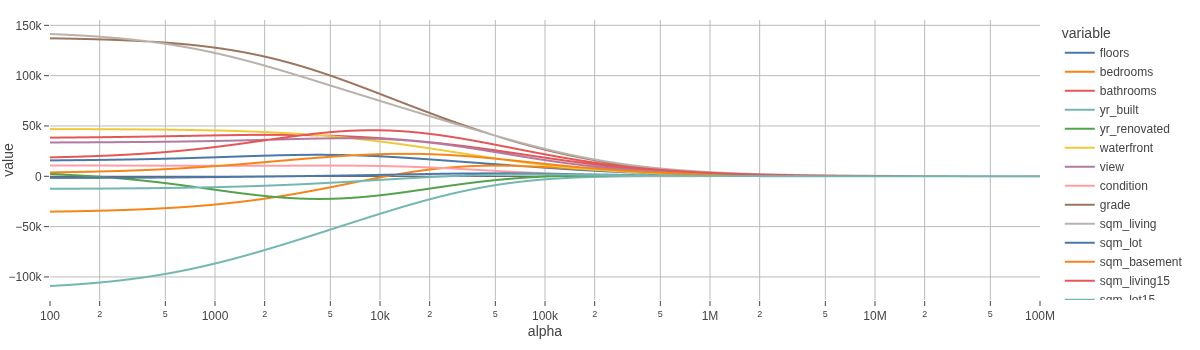

In [14]:
px.line(result, x='alpha', y=list(X_train_scaled.columns), log_x=True).show(renderer='png', width = 1200, height=350)

In [15]:
result = model_paths('lasso', X_train_scaled, y_train, 1, 7, 100, 10)

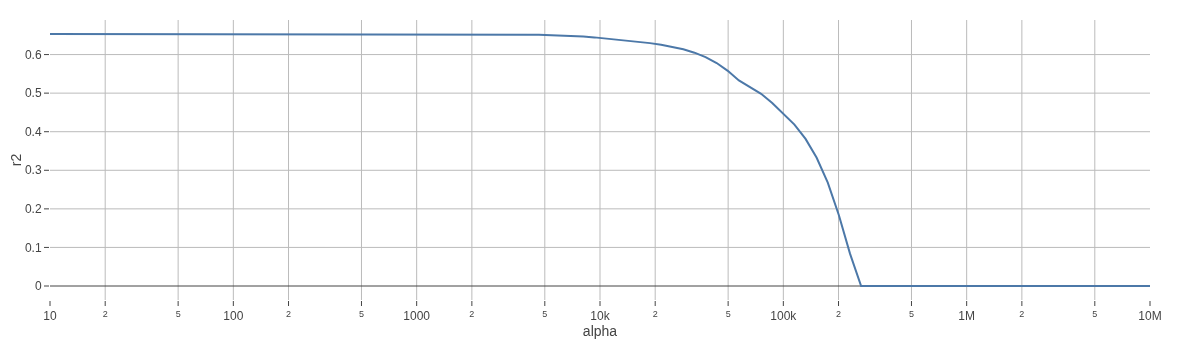

In [16]:
px.line(result, x='alpha', y='r2', log_x=True, width = 1200).show(renderer='png', width = 1200, height=350)

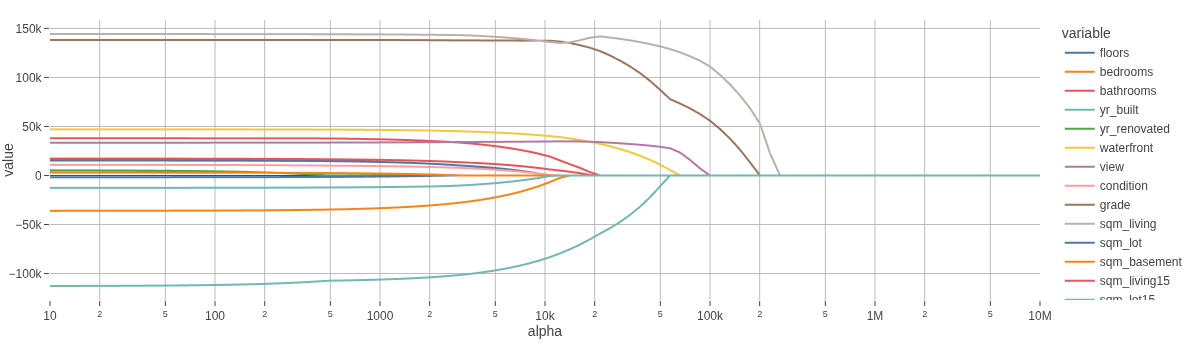

In [17]:
px.line(result, x='alpha', y=list(X_train_scaled.columns), log_x=True).show(renderer='png', width = 1200, height=350)

In [18]:
path_models['elastic_net'].l1_ratio = 0.999999

In [19]:
result = model_paths('elastic_net', X_train_scaled, y_train, 1, 7, 100, 10)

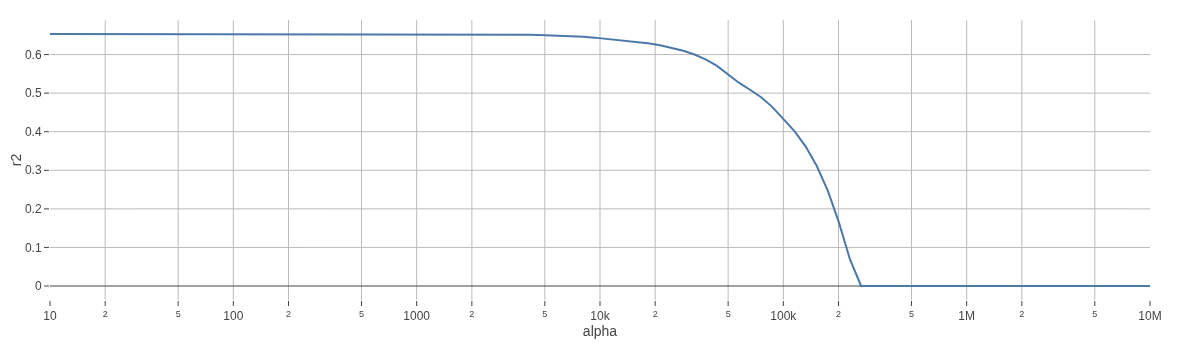

In [20]:
px.line(result, x='alpha', y='r2', log_x=True, width = 1200).show(renderer='png', width = 1200, height=350)

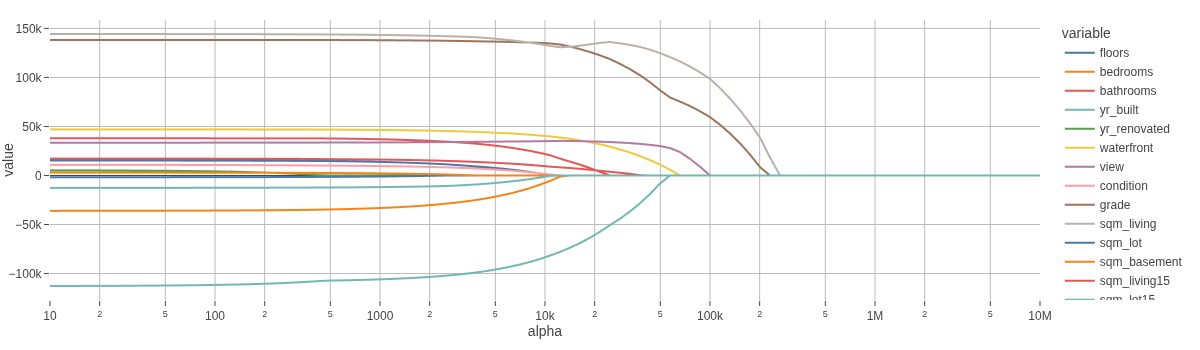

In [21]:
px.line(result, x='alpha', y=list(X_train_scaled.columns), log_x=True).show(renderer='png', width = 1200, height=350)

In [22]:
models = {
"Linear Regression": LinearRegression(),
"Ridge": Ridge(alpha=2000, random_state=42),
"Lasso": Lasso(alpha=22000, random_state=42, max_iter=10000),
"ElasticNet": ElasticNet(l1_ratio=0.999999, alpha=14200, random_state=42)
}

def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred_test = model.predict(X_test)
    y_pred_train = model.predict(X_train)

    mse = mean_squared_error(y_test, y_pred_test)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred_test)
    r2 = r2_score(y_test, y_pred_test)

    mse_train = mean_squared_error(y_train, y_pred_train)
    rmse_train = np.sqrt(mse_train)
    mae_train = mean_absolute_error(y_train, y_pred_train)
    r2_train = r2_score(y_train, y_pred_train)

    results = pd.DataFrame(data = 0.0, index=['r2', 'mse', 'rmse', 'mae'], columns=['test', 'train', 'ratio'])
    results.test=[r2, mse, rmse, mae]
    results.train=[r2_train, mse_train, rmse_train, mae_train]
    results.ratio=[100*r2/r2_train, 100*mse_train/mse, 100*rmse_train/rmse, 100*mae_train/mae]

    print('======== ', name, ' ========\n')
    print(results, '\n')

    print('Coefficients  (abs):')
    print('Intercept      ', round(model.intercept_, 6))
    print(pd.Series(data=np.abs(model.coef_), index=X_train.columns).sort_values(ascending=False))
    print('non-zero coeffs:', np.count_nonzero(model.coef_), '\n')

    cv = KFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(model, X_train, y_train, scoring='r2', cv=cv)
    print(f"CV R² mean: {cv_scores.mean():.4f} | std: {cv_scores.std():.4f}", '\n')

# Evaluate all models
for name, model in models.items():
    evaluate_model(name, model, X_train_scaled, X_test_scaled, y_train, y_test)

========  Linear Regression  ========

              test         train       ratio
r2    6.540027e-01  6.533348e-01  100.102236
mse   5.230673e+10  4.529133e+10   86.587958
rmse  2.287066e+05  2.128176e+05   93.052651
mae   1.432000e+05  1.386572e+05   96.827623 

Coefficients  (abs):
Intercept       537768.047947
sqm_living      144293.047259
grade           138176.688528
yr_built        112821.211190
waterfront       47058.355906
bathrooms        37949.845112
bedrooms         36042.176675
view             33432.949199
sqm_living15     17248.502431
floors           15303.058893
sqm_lot15        12622.021423
condition        10873.369242
yr_renovated      5387.443215
sqm_basement      2907.644655
sqm_lot           1759.950811
dtype: float64
non-zero coeffs: 14 

CV R² mean: 0.6495 | std: 0.0122 

========  Ridge  ========

              test         train      ratio
r2    6.459203e-01  6.464387e-01  99.919810
mse   5.352860e+10  4.619229e+10  86.294602
rmse  2.313625e+05  2.149239e+05

In [23]:
polynomial_features = PolynomialFeatures(degree=2, include_bias=False)
kc_poly_x = polynomial_features.fit_transform(kc_X)

In [ ]:
px.imshow(pd.DataFrame(polynomial_features.powers_,
                       columns=polynomial_features.feature_names_in_,
                       index=polynomial_features.get_feature_names_out(polynomial_features.feature_names_in_)).T
).update_layout(margin=dict(t=200)).update_xaxes(side='top', tickangle=270)

In [25]:
poly_X_train, poly_X_test, poly_y_train, poly_y_test = train_test_split(kc_poly_x, kc_y, test_size=0.2, random_state=42)

scaler = StandardScaler()
poly_X_train_scaled = scaler.fit_transform(poly_X_train)
poly_X_test_scaled = scaler.transform(poly_X_test)

In [26]:
sm.OLS(endog=poly_y_train, exog=sm.add_constant(poly_X_train)).fit().rsquared

np.float64(0.757097859296225)

In [27]:
result = model_paths('ridge', poly_X_train_scaled, poly_y_train, -2, 8, 100, 10)

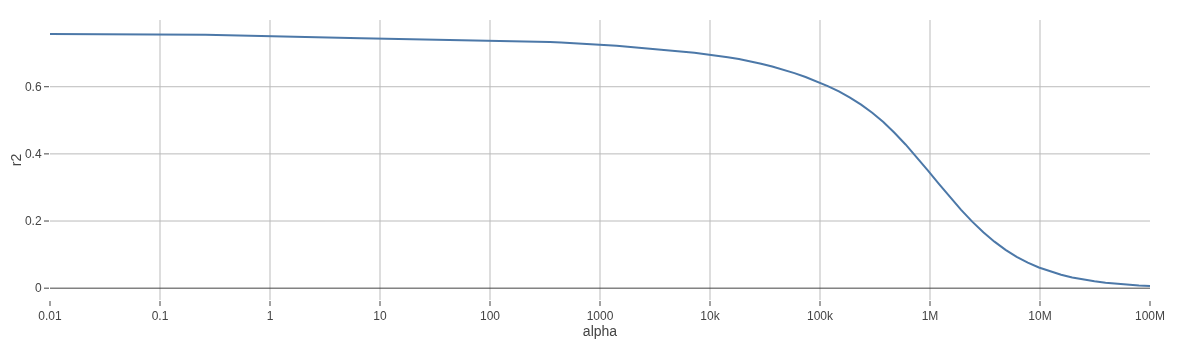

In [28]:
px.line(result, x='alpha', y='r2', log_x=True).show(renderer='png', width = 1200, height=350)

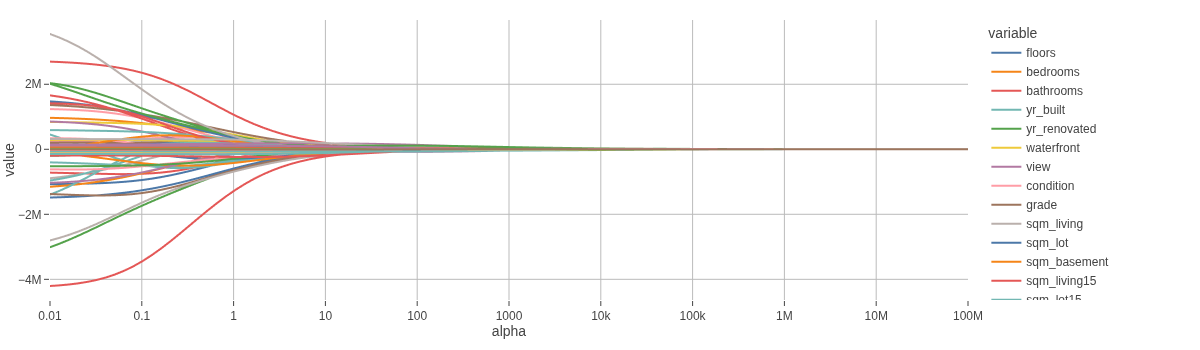

In [29]:
px.line(result, x='alpha', y=list(poly_X_train_scaled.columns), log_x=True).show(renderer='png', width = 1200, height=350)

In [30]:
result = model_paths('lasso', poly_X_train_scaled, poly_y_train, 3, 6, 100, 10)

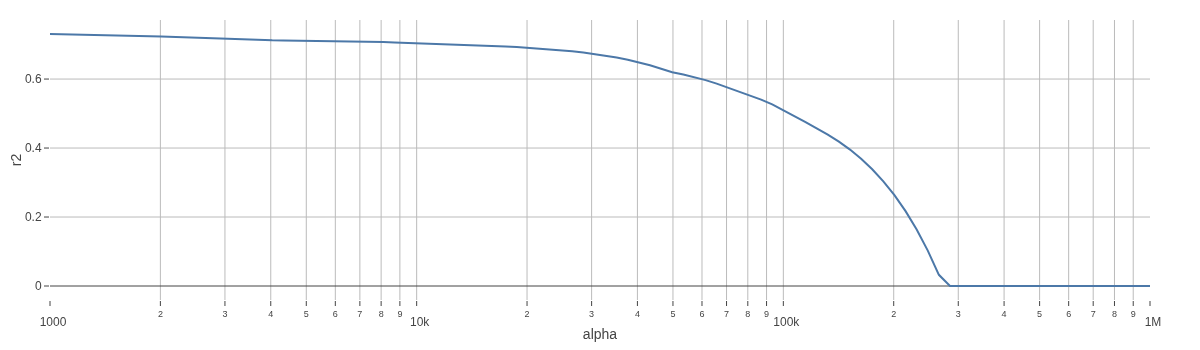

In [31]:
px.line(result, x='alpha', y='r2', log_x=True).show(renderer='png', width = 1200, height=350)

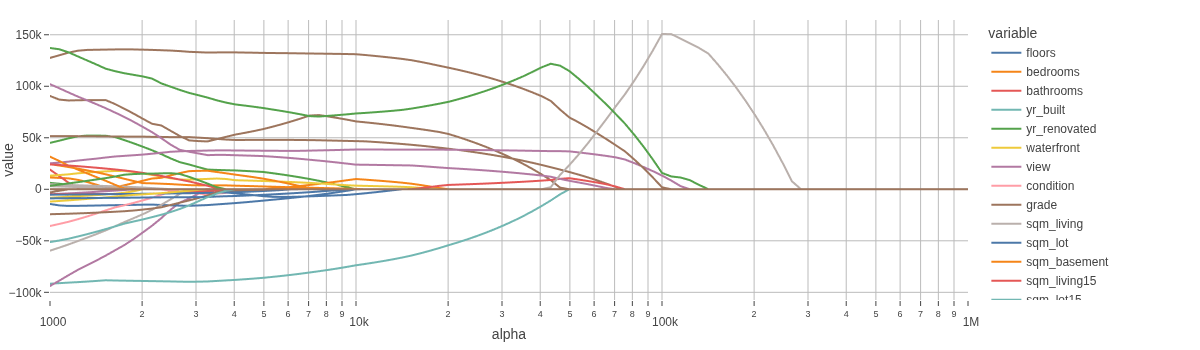

In [32]:
px.line(result, x='alpha', y=list(poly_X_train_scaled.columns), log_x=True).show(renderer='png', width = 1200, height=350)

In [33]:
evaluate_model('linear regression', LinearRegression(), poly_X_train_scaled, poly_X_test_scaled, poly_y_train, poly_y_test)

========  linear regression  ========

              test         train      ratio
r2    6.991798e-01  7.570979e-01  92.349991
mse   4.547701e+10  3.173483e+10  69.782137
rmse  2.132534e+05  1.781427e+05  83.535703
mae   1.300479e+05  1.214666e+05  93.401402 

Coefficients  (abs):
Intercept       537768.047947
yr_built sqm_living15      4.269657e+06
yr_renovated sqm_living    4.054853e+06
yr_renovated               3.637062e+06
yr_built sqm_living        3.177038e+06
sqm_living15               2.740053e+06
                               ...     
bedrooms sqm_lot15         2.605562e+03
waterfront sqm_lot         2.184951e+03
floors view                1.767227e+03
waterfront sqm_lot15       1.219030e+03
sqm_lot sqm_basement       8.030022e+02
Length: 119, dtype: float64
non-zero coeffs: 119 

CV R² mean: 0.7348 | std: 0.0307 



In [34]:
evaluate_model('ridge', Ridge(alpha=10, random_state=42), poly_X_train_scaled, poly_X_test_scaled, poly_y_train, poly_y_test)

========  ridge  ========

              test         train      ratio
r2    6.959126e-01  7.432504e-01  93.630975
mse   4.597093e+10  3.354398e+10  72.967800
rmse  2.144083e+05  1.831502e+05  85.421192
mae   1.315969e+05  1.239716e+05  94.205552 

Coefficients  (abs):
Intercept       537768.047947
yr_built sqm_living15     222281.109444
sqm_living15              197193.912264
grade sqm_living          192515.211025
grade sqm_living15        185328.278345
condition sqm_living15    181340.508411
                              ...      
bathrooms waterfront        1838.026781
floors view                 1528.536785
bedrooms waterfront         1226.243539
sqm_basement sqm_lot15      1161.926062
view sqm_living15            885.346363
Length: 119, dtype: float64
non-zero coeffs: 119 

CV R² mean: 0.7186 | std: 0.0341 



In [35]:
evaluate_model('lasso', Lasso(alpha=20000, random_state=42), poly_X_train_scaled, poly_X_test_scaled, poly_y_train, poly_y_test)

========  lasso  ========

              test         train      ratio
r2    6.582545e-01  6.908599e-01  95.280465
mse   5.166396e+10  4.038873e+10  78.175827
rmse  2.272971e+05  2.009695e+05  88.417095
mae   1.390944e+05  1.333252e+05  95.852334 

Coefficients  (abs):
Intercept       537768.047947
grade^2                      118111.096196
sqm_living^2                  84810.792214
yr_built                      54382.675679
bathrooms sqm_living          53785.651665
waterfront sqm_living         39439.607376
                                 ...      
sqm_basement sqm_living15         0.000000
sqm_basement sqm_lot15            0.000000
sqm_living15^2                    0.000000
sqm_living15 sqm_lot15            0.000000
sqm_lot15^2                       0.000000
Length: 119, dtype: float64
non-zero coeffs: 8 

CV R² mean: 0.6832 | std: 0.0272 

